In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('used_car_listings.csv',usecols=[9,10,11])

In [4]:
df.head()

,mileage,price,condition
0,46134,19919.0,good
1,16109,19480.0,good
2,173239,4556.0,good
3,36810,11536.0,fair
4,87749,14098.0,good


In [7]:
df.isnull().sum()

mileage      0
price        0
condition    0
dtype: int64

In [6]:
df['condition'].fillna(df['condition'].value_counts().index[0],inplace=True)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_14384\2052693466.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['condition'].fillna(df['condition'].value_counts().index[0],inplace=True)


In [8]:
df.describe()

,mileage,price
count,2068.000000,2068.000000
mean,115626.364603,9182.621857
std,80971.112603,9964.093618
min,0.000000,1140.000000
25%,57683.250000,2323.750000
50%,99212.000000,5448.500000
75%,159291.500000,11946.750000
max,418428.000000,72641.000000


In [9]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.head()

,mileage,price
932,108268,5430.0
1523,274780,1208.0
1111,0,28595.0
1679,95435,7609.0
123,77534,3971.0


C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_14384\4135090196.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['mileage'])


Text(0.5, 1.0, 'mileage QQ plot')

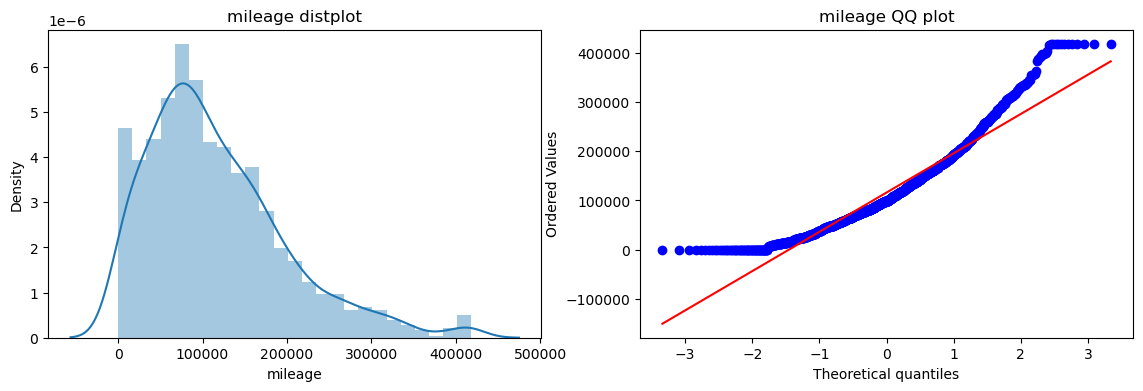

In [10]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
sns.distplot(x_train['mileage'])
plt.title('mileage distplot')

plt.subplot(122)
stats.probplot(x_train['mileage'], dist="norm", plot=plt)
plt.title('mileage QQ plot')    

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_14384\1563871662.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['price'])


Text(0.5, 1.0, 'price QQ plot')

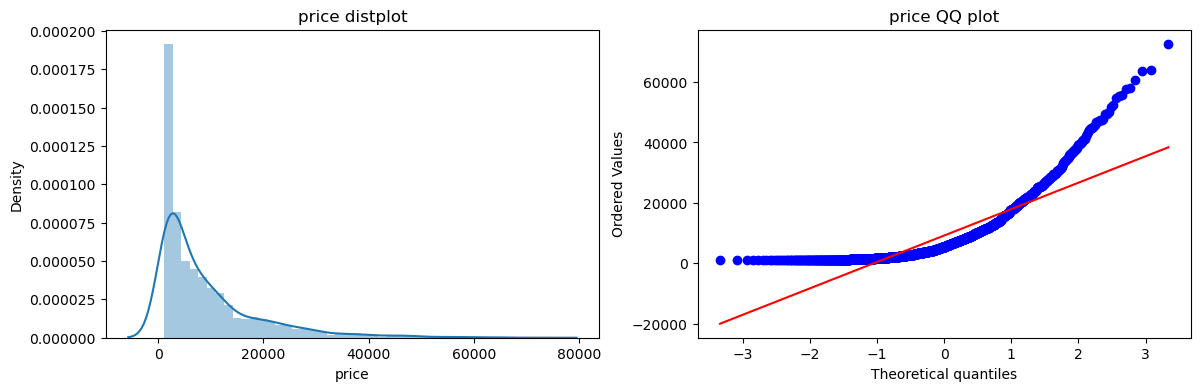

In [11]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
sns.distplot(x_train['price'])
plt.title('price distplot')

plt.subplot(122)
stats.probplot(x_train['price'], dist="norm", plot=plt)
plt.title('price QQ plot')    

In [18]:
# label Encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_transformed = le.fit_transform(y_train)
y_test_transformed = le.fit_transform(y_test)

y_transformed = le.fit_transform(y)

y_train_transformed = pd.DataFrame(y_train_transformed)
y_train_transformed.value_counts()

0
2    684
0    476
1    301
3     82
5     77
4     34
Name: count, dtype: int64

In [13]:
# model training before power Transformation

In [16]:
lr = LinearRegression()

lr.fit(x_train ,y_train_transformed)

y_pred = lr.predict(x_test)

r2_score(y_test_transformed,y_pred)

0.008180856256462254

In [19]:
np.mean(cross_val_score(lr, x, y_transformed, scoring="r2"))

-0.004309813854420863

In [ ]:
# Power_Transformer[box-cox]

In [21]:
pt = PowerTransformer(method='box-cox')

x_train_transformed = pt.fit_transform(x_train+0.00000001)
x_test_transformed = pt.fit_transform(x_test+0.00000001)

pd.DataFrame({'col':x_train.columns,'Lambdas':pt.lambdas_})

,col,Lambdas
0,mileage,0.350450
1,price,-0.086531


In [22]:
#QQ Plot Before & After Transformation

Text(0.5, 1.0, 'mileage QQ plot')

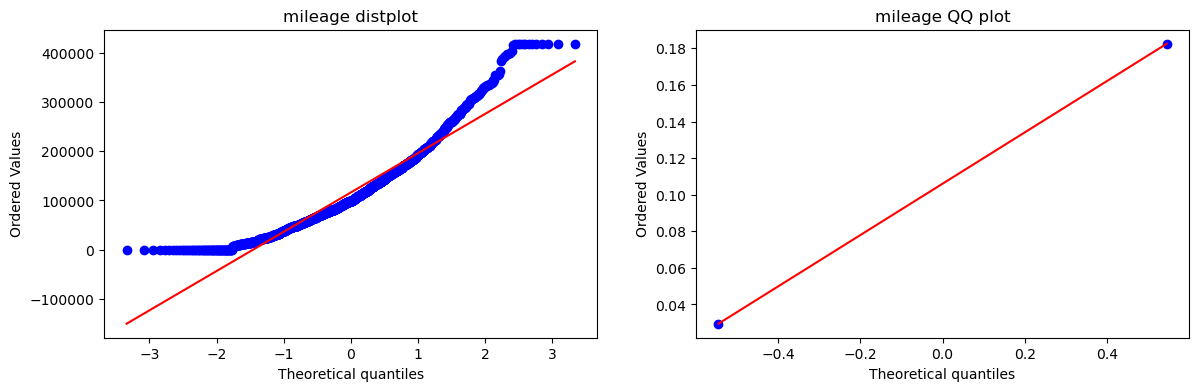

In [24]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
stats.probplot(x_train['mileage'], dist="norm", plot=plt)
plt.title('mileage distplot')

plt.subplot(122)
stats.probplot(x_train_transformed[0], dist="norm", plot=plt)
plt.title('mileage QQ plot')    

Text(0.5, 1.0, 'price QQ plot')

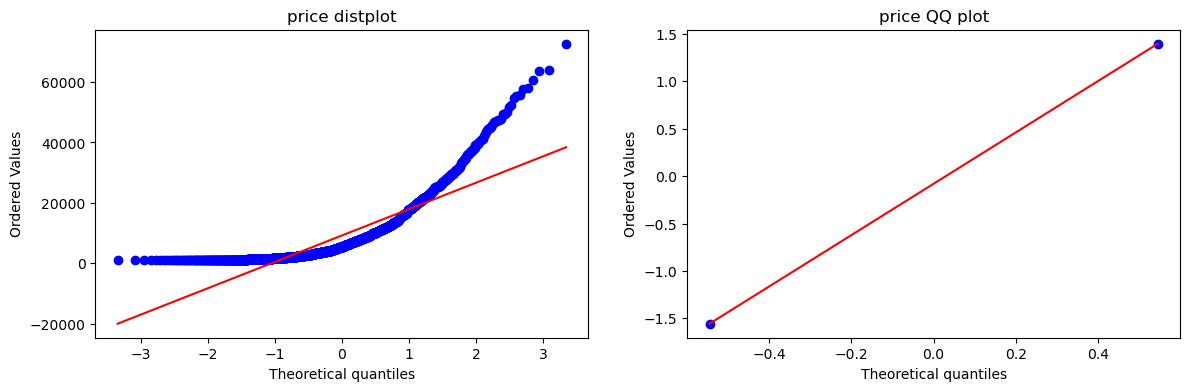

In [27]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
stats.probplot(x_train['price'], dist="norm", plot=plt)
plt.title('price distplot')

plt.subplot(122)
stats.probplot(x_train_transformed[1], dist="norm", plot=plt)
plt.title('price QQ plot')    

In [ ]:
# model training After power_transformer[box-cox] 

In [30]:
lr = LinearRegression()

lr.fit(x_train_transformed ,y_train_transformed)

y_pred2 = lr.predict(x_test_transformed)

r2_score(y_test_transformed,y_pred2)

0.0158027127961754

In [34]:
x_transformed = pt.fit_transform(x+0.0000001)
np.mean(cross_val_score(lr, x_transformed, y_transformed, scoring="r2"))

-9.250500192323763e-05

In [35]:
# Power_Transformer[yeo-johnson]

In [36]:
pt1 = PowerTransformer()

x_train_transformed2 = pt1.fit_transform(x_train)
x_test_transformed2 = pt1.fit_transform(x_test)

pd.DataFrame({'col':x_train.columns,'Lambdas':pt1.lambdas_})

,col,Lambdas
0,mileage,0.497607
1,price,-0.086714


Text(0.5, 1.0, 'mileage QQ plot')

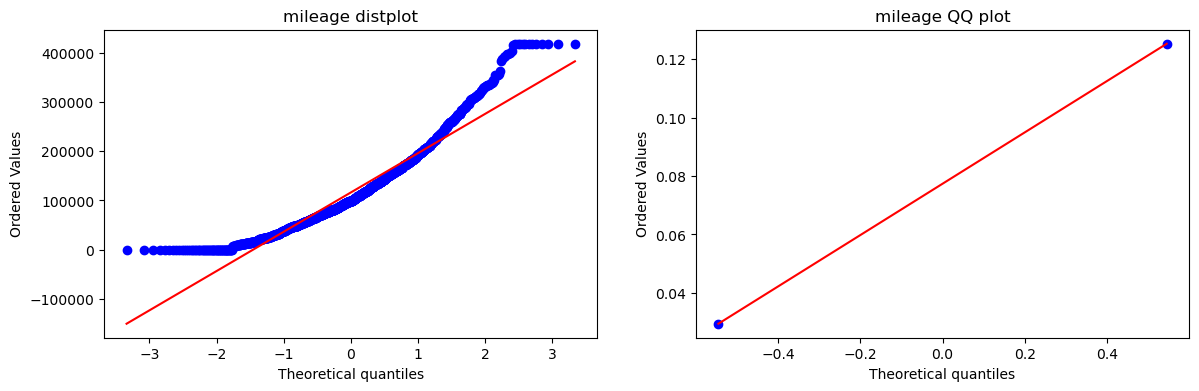

In [38]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
stats.probplot(x_train['mileage'], dist="norm", plot=plt)
plt.title('mileage distplot')

plt.subplot(122)
stats.probplot(x_train_transformed2[0], dist="norm", plot=plt)
plt.title('mileage QQ plot')    

Text(0.5, 1.0, 'price QQ plot')

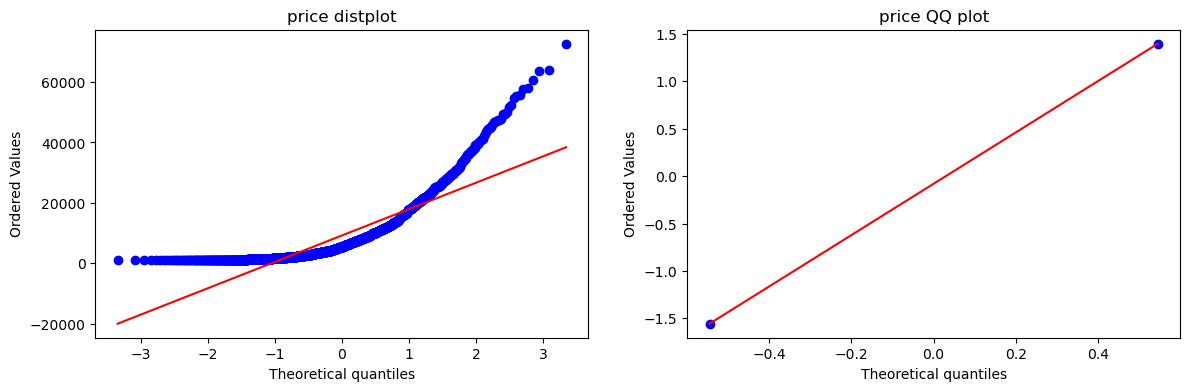

In [39]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
stats.probplot(x_train['price'], dist="norm", plot=plt)
plt.title('price distplot')

plt.subplot(122)
stats.probplot(x_train_transformed[1], dist="norm", plot=plt)
plt.title('price QQ plot')    

In [ ]:
# model training After power_transformer[Yeo-Johnson] 

In [42]:
lr = LinearRegression()

lr.fit(x_train_transformed2 ,y_train_transformed)

y_pred2 = lr.predict(x_test_transformed2)

r2_score(y_test_transformed,y_pred2)

0.019147820886189604

In [43]:
x_transformed2 = pt1.fit_transform(x)
np.mean(cross_val_score(lr, x_transformed2, y_transformed, scoring="r2"))

0.0019351962019119595